### ¿Cuáles son las características predominantes de los pacientes según su nivel de riesgo de enfermedad cardíaca?
En general, mayores valores de edad, presión arterial sistólica y diastólica, colesterol, índice de masa corporal  y puntaje de riesgo cardíaco, además de hábitos de vida menos saludables, como menor actividad física y una mayor frecuencia de tabaquismo. Por el contrario, los pacientes con riesgo bajo muestran mejores indicadores clínicos y estilos de vida más saludables, mientras que los pacientes con riesgo medio presentan características intermedias entre ambos grupos. El análisis de correlación confirmó que variables como la presión arterial, el colesterol, la edad y el índice de masa corporal mantienen una relación importante con el riesgo de enfermedad cardíaca.


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno
import missingno as msno 
import janitor 
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from upsetplot import UpSet,from_indicators
from scipy.stats import norm 
import sys
import os
sys.path.insert(0, os.path.abspath("."))
import upsetplot
print(upsetplot.__file__)




c:\Users\KEVIN CAMPINES\Documents\ANALISIS DE DATOS EN COMPUTACIÓN\primer entregable proyecto\upsetplot\__init__.py


## 1. Analisis preliminar

In [2]:
df = pd.read_csv('cardiovascular_risk_dataset.csv',sep=';')
df = df.drop(['Patient_ID'],axis='columns')
df.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


variable nulas en el dataset 


In [3]:
df.isnull().sum()


age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

In [4]:
print (f'cantidad de datos y de columnas es:',df.shape)

cantidad de datos y de columnas es: (5500, 16)


tipo de dato para cada instancia

In [5]:
df.dtypes

age                                   int64
bmi                                 float64
systolic_bp                           int64
diastolic_bp                          int64
cholesterol_mg_dl                     int64
resting_heart_rate                    int64
smoking_status                          str
daily_steps                           int64
stress_level                          int64
physical_activity_hours_per_week    float64
sleep_hours                         float64
family_history_heart_disease            str
diet_quality_score                    int64
alcohol_units_per_week              float64
heart_disease_risk_score            float64
risk_category                           str
dtype: object

## Descripcion del dataset
como se puede ver en el count en ninguan instancia hay valores nulos, luego se puede ver el promedio de los datos, la desviacion estandar, el valor minimo para cada intancia, luego tenomos los cuartiles 25%,50%(la mediana),75% y el max que es el valor maximo registrado en cada intasncia. 

In [6]:
df.describe()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


## Moda del dataset 
ya que en el describe no se puede ver la moda de cada intancia lo tenemos que hacer por separado y ademas quitamos las variable que no son numericas

In [7]:
df.select_dtypes(include=['int64','float64']).mode().iloc[0]

age                                  54.0
bmi                                  29.0
systolic_bp                         147.0
diastolic_bp                         93.0
cholesterol_mg_dl                   231.0
resting_heart_rate                   74.0
daily_steps                         500.0
stress_level                          4.0
physical_activity_hours_per_week      0.0
sleep_hours                           6.8
diet_quality_score                    4.0
alcohol_units_per_week                0.5
heart_disease_risk_score              0.0
Name: 0, dtype: float64

## suma de los nivel de riego de todos los pacientes 


In [8]:
df['risk_category'].value_counts()

risk_category
Medium    2244
Low       1838
High      1418
Name: count, dtype: int64

nivel de riego en porcentaje con el normalize 

In [9]:
df['risk_category'].value_counts(normalize=True)*100

risk_category
Medium    40.800000
Low       33.418182
High      25.781818
Name: proportion, dtype: float64

## En esta fase podemos responder la siguiente pregunta ¿Cómo son las características de los pacientes del conjunto de datos?

Respuesta: El conjunto de datos está conformado por pacientes con variables clínicas y hábitos de vida, como edad, IMC, presión arterial, colesterol, actividad física, sueño, tabaquismo y antecedentes familiares. La distribución de la variable risk_category muestra que la mayor proporción de pacientes pertenece al riesgo medio, seguida por riesgo bajo y riesgo alto.

## visualizacion de los datos 

como se puede ver segun este dataset se presenta pacientes con un riego medio que corresponde al 40% presentado en la fase de descripcion, seguido de riesgo bajo (33%) y por ultimo los pacientes con alto riesgo. 

Text(0, 0.5, 'cantidad de pacientes')

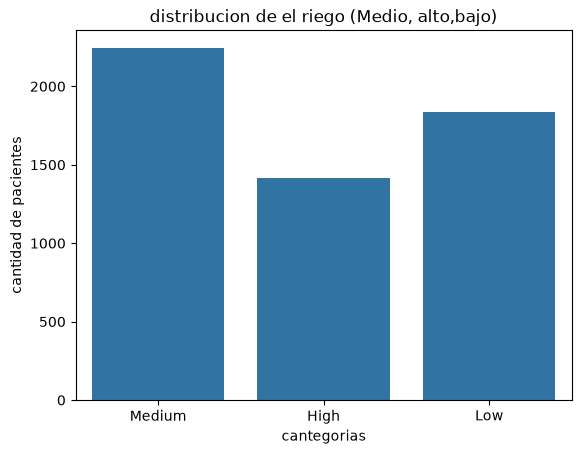

In [10]:
sns.countplot(data=df , x = 'risk_category')
plt.title('distribucion de el riego (Medio, alto,bajo)')
plt.xlabel('cantegorias')
plt.ylabel('cantidad de pacientes')

se creo un grafico de caja, se puede ver cómo el nivel de riesgo tiende a incrementarse a medida que aumenta la edad de los pacientes. En la categoría de riesgo bajo , la mediana se sitúa aproximadamente en los 34 años, mientras que en el grupo de riesgo medio  esta cifra asciende a una mediana cercana a los 55 años. Por último, en la categoría de riesgo alto, la mediana se posiciona marcadamente por encima de los 70 años, consolidando esta tendencia.

Sin embargo, el gráfico también permite observar la existencia de valores atípicos (outliers) en los extremos opuestos de la distribución. Por un lado, en el grupo de riesgo alto se detecta la presencia de personas jóvenes que registran un nivel de riesgo elevado. En la categoría de riesgo bajo ocurre el fenómeno contrario, identificándose a un grupo de personas de edad avanzada que, a pesar de su longevidad, se mantienen en un rango de riesgo bajo.

c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


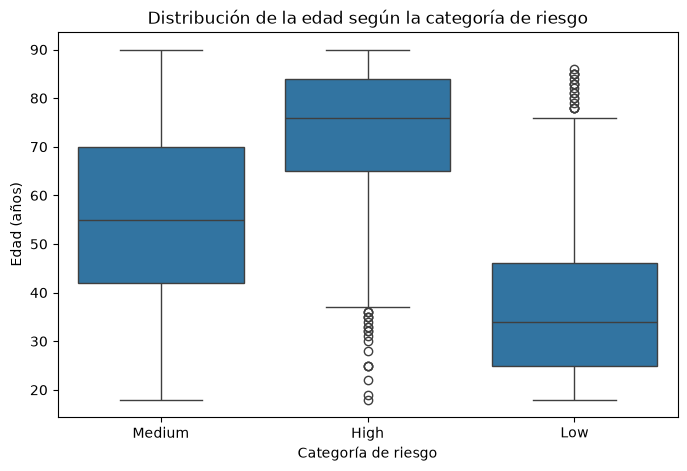

In [11]:

plt.figure(figsize=(8,5))

sns.boxplot(data=df,x='risk_category', y='age')

plt.title('Distribución de la edad según la categoría de riesgo')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Edad (años)')

plt.show()

en cuanto al grafico de caja con respecto a el nivel de masa coorporal se aprecian valores atípicos claros en todos los niveles: la categoría de riesgo alto incluye de forma excepcional a un par de pacientes delgados (BMI de 21 y 23), mientras que las categorías de riesgo bajo y medio presentan a varias personas con obesidad severa (de hasta 35 y 38 de BMI) que logran mantenerse en niveles de peligro controlados esto podria deberse a otros factores.

C:\Users\KEVIN CAMPINES\AppData\Local\Temp\ipykernel_12788\299994109.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='risk_category', y='bmi', order=['Low', 'Medium', 'High'], palette='Set2')
c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\KEVIN CAMPINES\AppData\Local\Py

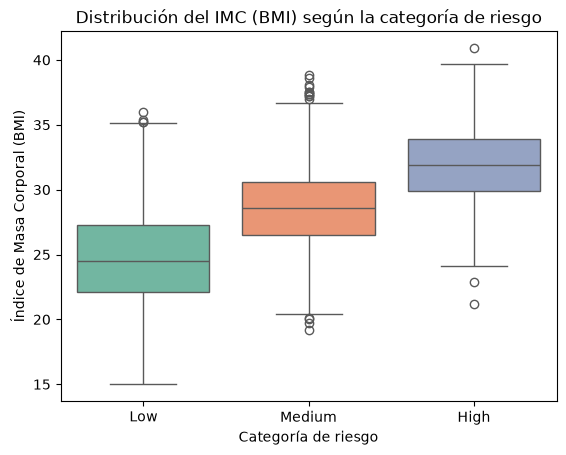

In [12]:

sns.boxplot(data=df, x='risk_category', y='bmi', order=['Low', 'Medium', 'High'], palette='Set2')

plt.title('Distribución del IMC (BMI) según la categoría de riesgo')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Índice de Masa Corporal (BMI)')

plt.show()

cholesterol_mg_dl	Boxplot
stress_level	Boxplot
daily_steps	Boxplot
sleep_hours	Boxplot
physical_activity_hours_per_week	Boxplot


las medianas aumentan notablemente desde el riesgo bajo (aprox. 212 ), pasando por el medio (aprox. 243 ), hasta el alto (aprox. 271 mg/dL). La dispersión interna  se mantiene bastante similar en los tres grupos, aunque el rango general de la categoría de riesgo alto se desplaza significativamente hacia valores peligrosos, alcanzando máximos normales de hasta 320 mg/dL. Finalmente, se observan valores atípicos (outliers) en todas las categoría

c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


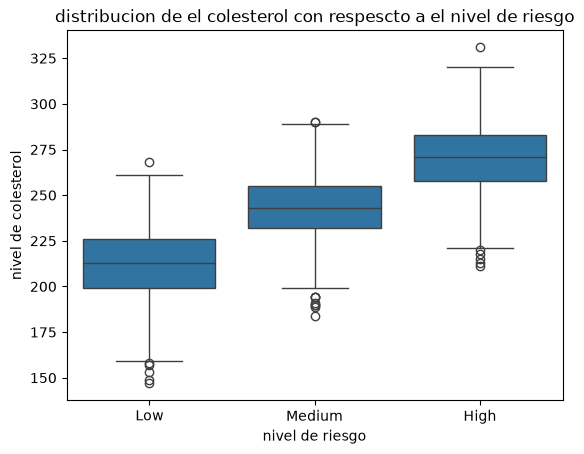

In [13]:
sns.boxplot(data=df,x='risk_category',y='cholesterol_mg_dl',order=['Low', 'Medium', 'High'])
plt.title('distribucion de el colesterol con respescto a el nivel de riesgo')
plt.xlabel('nivel de riesgo')
plt.ylabel('nivel de colesterol')
plt.show()

c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


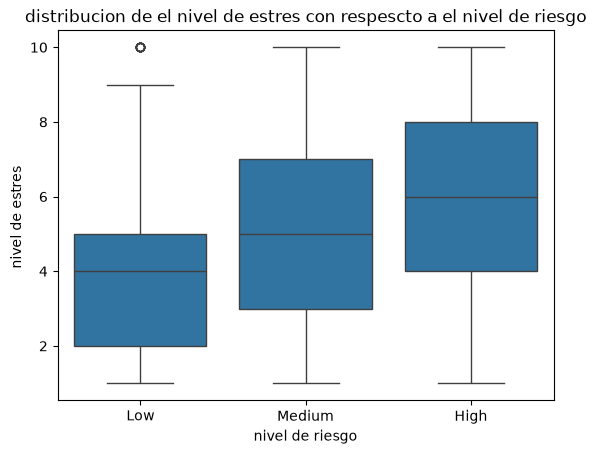

In [14]:
sns.boxplot(data=df,x='risk_category',y='stress_level',order=['Low', 'Medium', 'High'])
plt.title('distribucion de el nivel de estres con respescto a el nivel de riesgo')
plt.xlabel('nivel de riesgo')
plt.ylabel('nivel de estres ')
plt.show()

esta garfica indica que los pacientes con mayor nivel de riesgo tienden a caminar significativamente menos. Las medianas disminuyen de forma escalonada a medida que el riesgo aumenta, cayendo desde aproximadamente 7,500 pasos en el riesgo bajo, a unos 5000 en el medio, y situándose por debajo de los 4,000 pasos diarios en el riesgo alto. Asimismo, el grupo de riesgo bajo exhibe la mayor variabilidad y los valores máximos más altos superan los 16,000 pasos, mientras que las categorías media y alta presentan múltiples valores atípicos en la parte superior, reflejando casos de personas muy activas que, a pesar de caminar bastante, registran un riesgo moderado o elevado.

c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


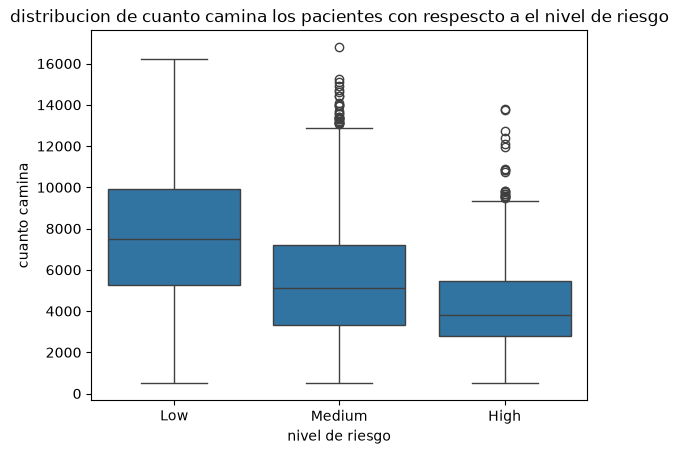

In [15]:
sns.boxplot(data=df,x='risk_category',y='daily_steps',order=['Low', 'Medium', 'High'])
plt.title('distribucion de cuanto camina los pacientes con respescto a el nivel de riesgo')
plt.xlabel('nivel de riesgo')
plt.ylabel('cuanto camina')
plt.show()

Segun la grafica entre los pacientes con distintos riegos la cantidad de horas que duermenen en general es casi igual aunque hay una leve diferencia con los pacientes de alto riesgo, ademas se puede ver que hay outliers en las tres.

c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


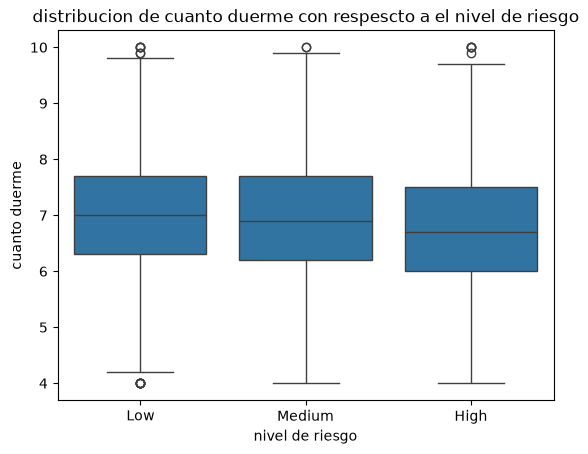

In [16]:
sns.boxplot(data=df,x='risk_category',y='sleep_hours',order=['Low', 'Medium', 'High'])
plt.title('distribucion de cuanto duerme con respescto a el nivel de riesgo')
plt.xlabel('nivel de riesgo')
plt.ylabel('cuanto duerme')
plt.show()

como se puede ver el fumar se ve mas presente en el alto riesgo casi el 40% de las personas que fuma esta en un riesgo alto,  

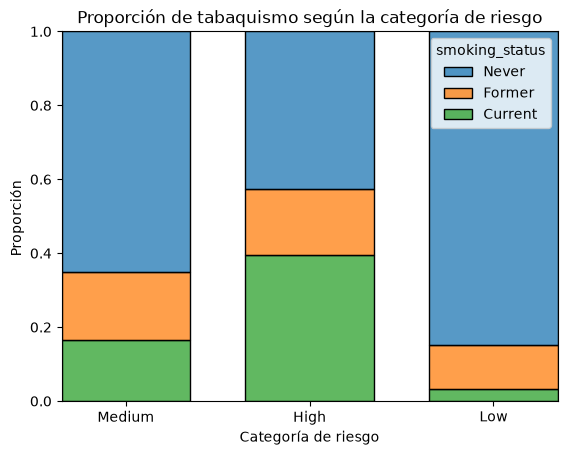

In [17]:
sns.histplot(data=df, x="risk_category", hue="smoking_status",hue_order=["Never", "Former", "Current"],multiple="fill",stat='percent', shrink=0.7 )

plt.title("Proporción de tabaquismo según la categoría de riesgo")
plt.xlabel("Categoría de riesgo")
plt.ylabel("Proporción ")
plt.show()

El incremento progresivo y escalonado del segmento naranja a medida que se transita de Low a High demuestra que la herencia genética es una característica predominante y de considerable peso epidemiológico para el desarrollo de un perfil de riesgo severo.

Text(0, 0.5, 'Proporción')

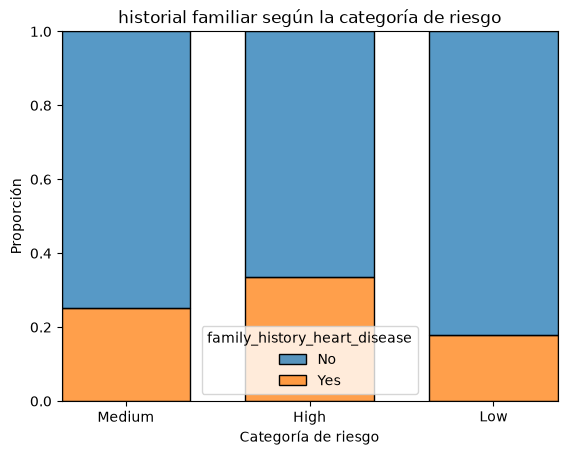

In [18]:
sns.histplot(
    data=df,x="risk_category",hue="family_history_heart_disease",multiple="fill",stat="percent",shrink=0.7)

plt.title("historial familiar según la categoría de riesgo")
plt.xlabel("Categoría de riesgo")
plt.ylabel("Proporción")

## ¿Qué diferencias presentan los pacientes de riesgo bajo, medio y alto según sus características y hábitos de vida?

Respuesta: Las visualizaciones permiten comparar cómo cambian variables como edad, IMC, colesterol, presión arterial, estrés, actividad física y sueño entre las categorías de riesgo. En general, los pacientes de mayor riesgo tienden a presentar valores más elevados en variables clínicas y hábitos menos saludables.

## Graficas de Análisis de valores faltantes 

In [19]:
%run pandas-missing-extension.ipynb

ya que no hay valores faltantes como lo presenta las siguientes graficas no se puede hacer ningun metodo de imputaion.


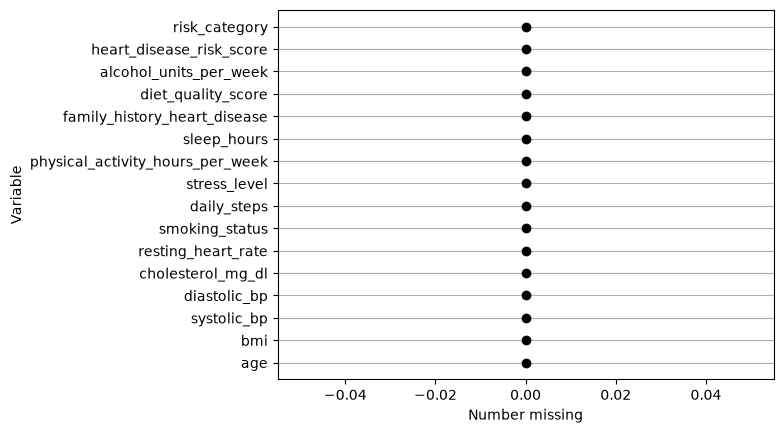

In [20]:
df.missing.missing_variable_plot()

<Axes: >

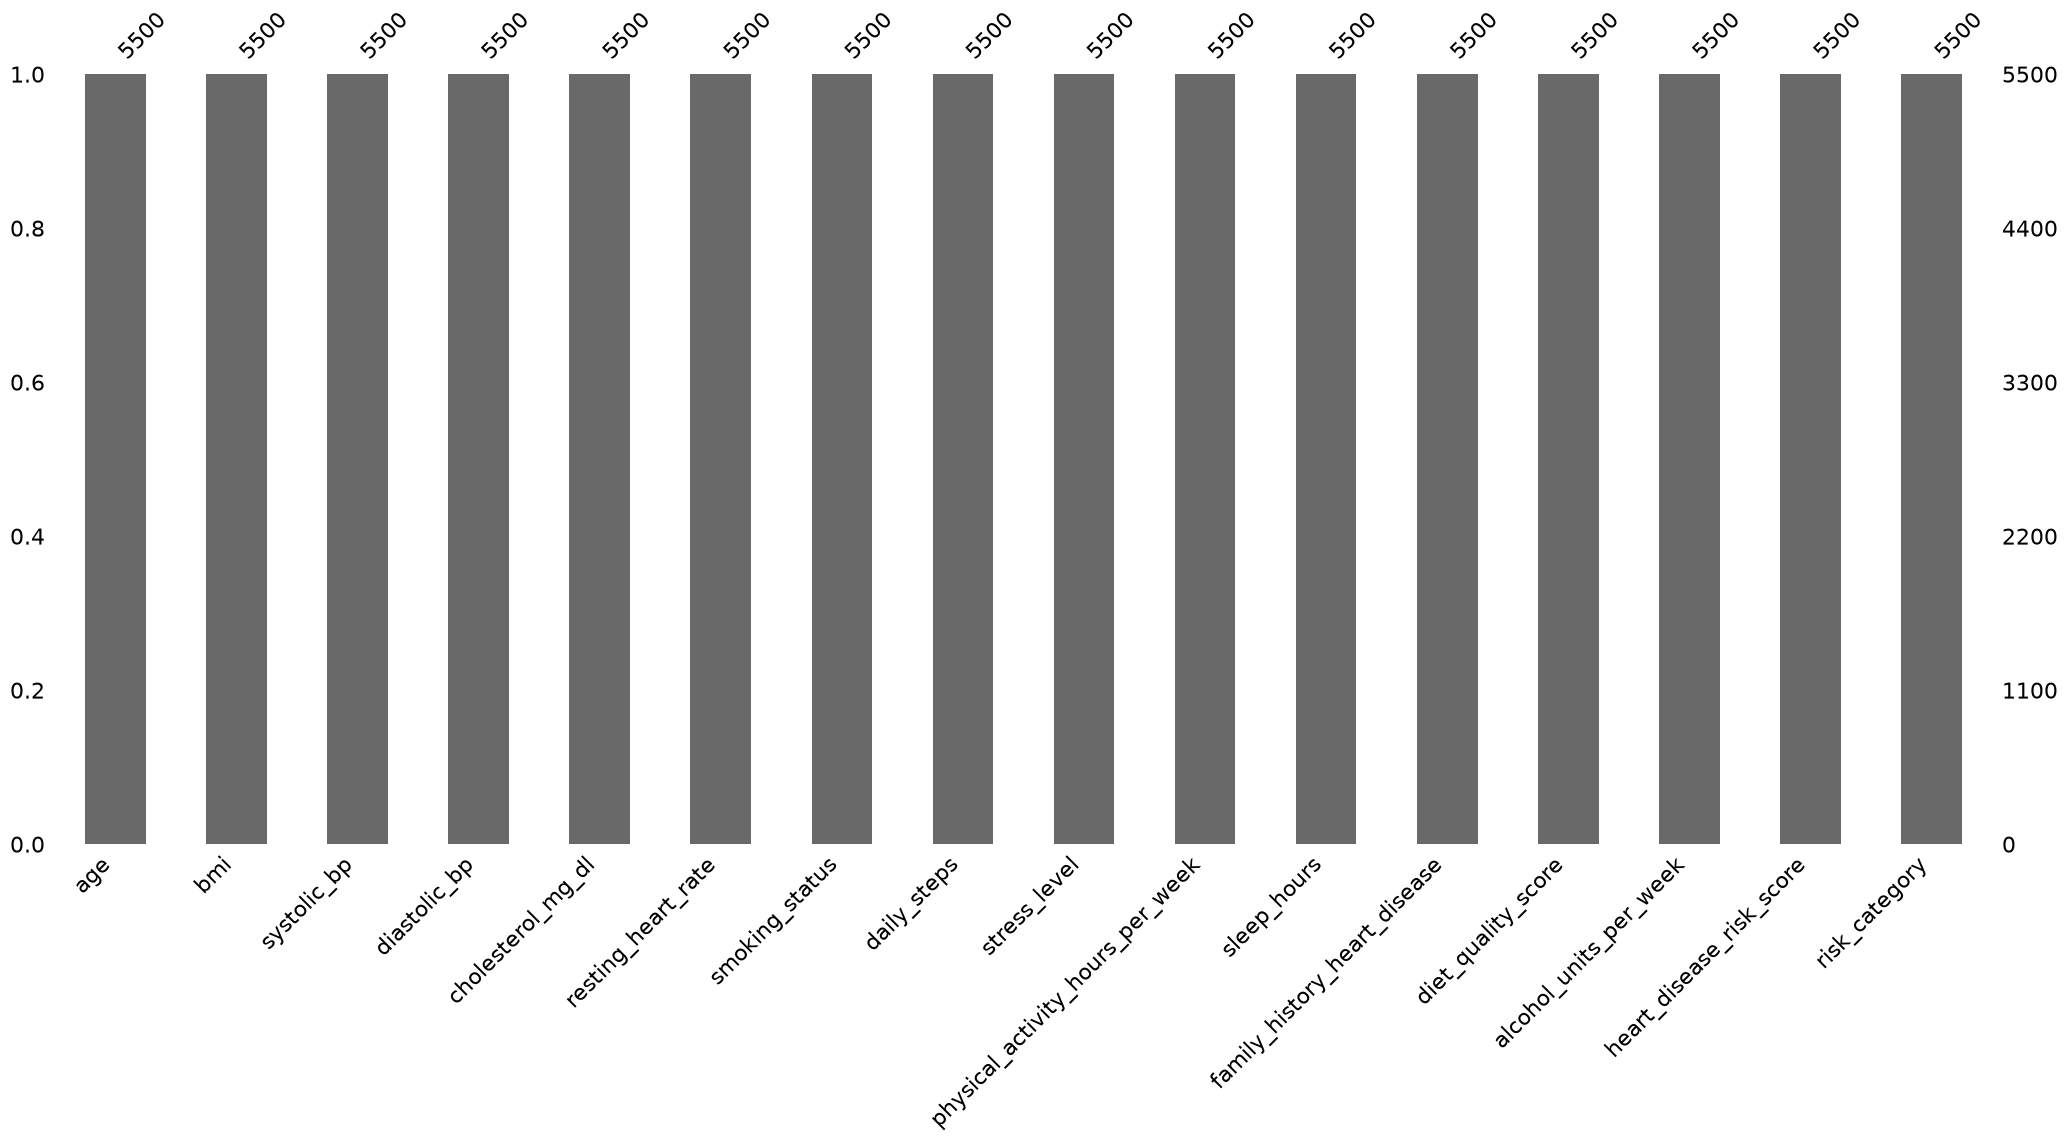

In [21]:
missingno.bar(df=df)

## Usando upsetplto 

c:\Users\KEVIN CAMPINES\Documents\ANALISIS DE DATOS EN COMPUTACIÓN\primer entregable proyecto\upsetplot\plotting.py:964: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  orig_ax.set_xlim(max_total, 0)


{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

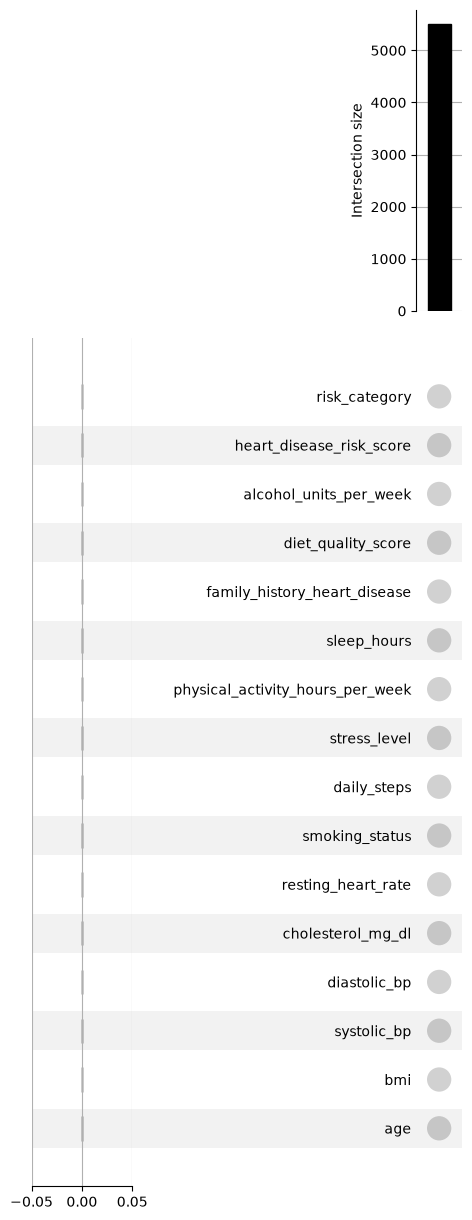

In [22]:
(
    df.missing.missing_upsetplot(
        variables=[
            "age",
            "bmi",
            "systolic_bp",
            "diastolic_bp",
            "cholesterol_mg_dl",
            "resting_heart_rate",
            "smoking_status",
            "daily_steps",
            "stress_level",
            "physical_activity_hours_per_week",
            "sleep_hours",
            "family_history_heart_disease",
            "diet_quality_score",
            "alcohol_units_per_week",
            "heart_disease_risk_score",
            "risk_category",
        ],
        element_size=50,
    )
)

## El conjunto de datos contiene valores faltantes que puedan afectar el análisis y los modelos predictivos?

Respuesta: Los gráficos de Missingno y UpSetPlot permitieron verificar la presencia de valores faltantes en el dataset. De acuerdo con el análisis realizado, no fue necesario aplicar procesos de imputación o eliminación de variables, por lo que el conjunto de datos se consideró apto para continuar con el análisis.

## Análisis de Correlación entre columnas del dataset

In [23]:
corr = df.corr(numeric_only=True)
corr


,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
age,1.000000,0.246300,0.718108,0.647239,0.661048,0.001981,-0.008763,-0.000405,-0.004214,-0.002322,0.009501,-0.005852,0.694286
bmi,0.246300,1.000000,0.615659,0.554239,0.768706,0.509978,-0.622660,0.313794,-0.676245,-0.079921,-0.817546,0.311838,0.713077
systolic_bp,0.718108,0.615659,1.000000,0.905337,0.766537,0.369686,-0.384431,0.421383,-0.400191,-0.111325,-0.398081,0.290831,0.901038
diastolic_bp,0.647239,0.554239,0.905337,1.000000,0.692246,0.342111,-0.339437,0.389865,-0.356744,-0.110172,-0.356313,0.254808,0.813140
cholesterol_mg_dl,0.661048,0.768706,0.766537,0.692246,1.000000,0.345943,-0.447553,0.230487,-0.456274,-0.059209,-0.636478,0.217506,0.852483
resting_heart_rate,0.001981,0.509978,0.369686,0.342111,0.345943,1.000000,-0.562579,0.534913,-0.732027,-0.131529,-0.483224,0.347258,0.428760
daily_steps,-0.008763,-0.622660,-0.384431,-0.339437,-0.447553,-0.562579,1.000000,-0.404731,0.730745,0.136136,0.660004,-0.408799,-0.478631
stress_level,-0.000405,0.313794,0.421383,0.389865,0.230487,0.534913,-0.404731,1.000000,-0.395330,-0.226630,-0.329363,0.374151,0.377445
physical_activity_hours_per_week,-0.004214,-0.676245,-0.400191,-0.356744,-0.456274,-0.732027,0.730745,-0.395330,1.000000,0.106789,0.639595,-0.398362,-0.520258
sleep_hours,-0.002322,-0.079921,-0.111325,-0.110172,-0.059209,-0.131529,0.136136,-0.226630,0.106789,1.000000,0.077977,-0.183538,-0.105379


In [24]:
vmaxCor =corr.max().max()
vminCor = corr.min().min()

Como se puede ver la variables con correlacion positiva son systolic_bp y diastolic_bp con 0.91 esto nos indica que si sube una presion sube la otra, heart_disease_risk_score con systolic_bp 0.90, cholesterol_mg_dl 0.85 y diastolic_bp 0.81, Esto indica que las presiones y el colesterol son los factores que más empujan al alza el puntaje de riesgo del paciente y el indicie de masa corporal (bmi) con el colesterol con 0.77 a maya volumen de masa mayor el colesterol.

En cuanto a correalcion negativa se presentan diet_quality_score y bmi con -0.82 esto basicmente no dice que una buena calidad de alimentacion genera menos masa cooporal, otra es physical_activity_hours_per_week y resting_heart_rate esto nos deja claro que mas hora de ejercicio reduce la fecuencia cardiaca en estado de reposo, daily_steps con bmi -0.62 mientras se camine mas se reduce las masa, pasa lo mismo con daily_steps y resting_heart_rate que tienen un 
-0.56.

En cuanto a las variables bastantes relacionadas estan systolic_bp, diastolic_bp, cholesterol_mg_dl y bmi ya que estan por encima de los 0.55  y las otras son

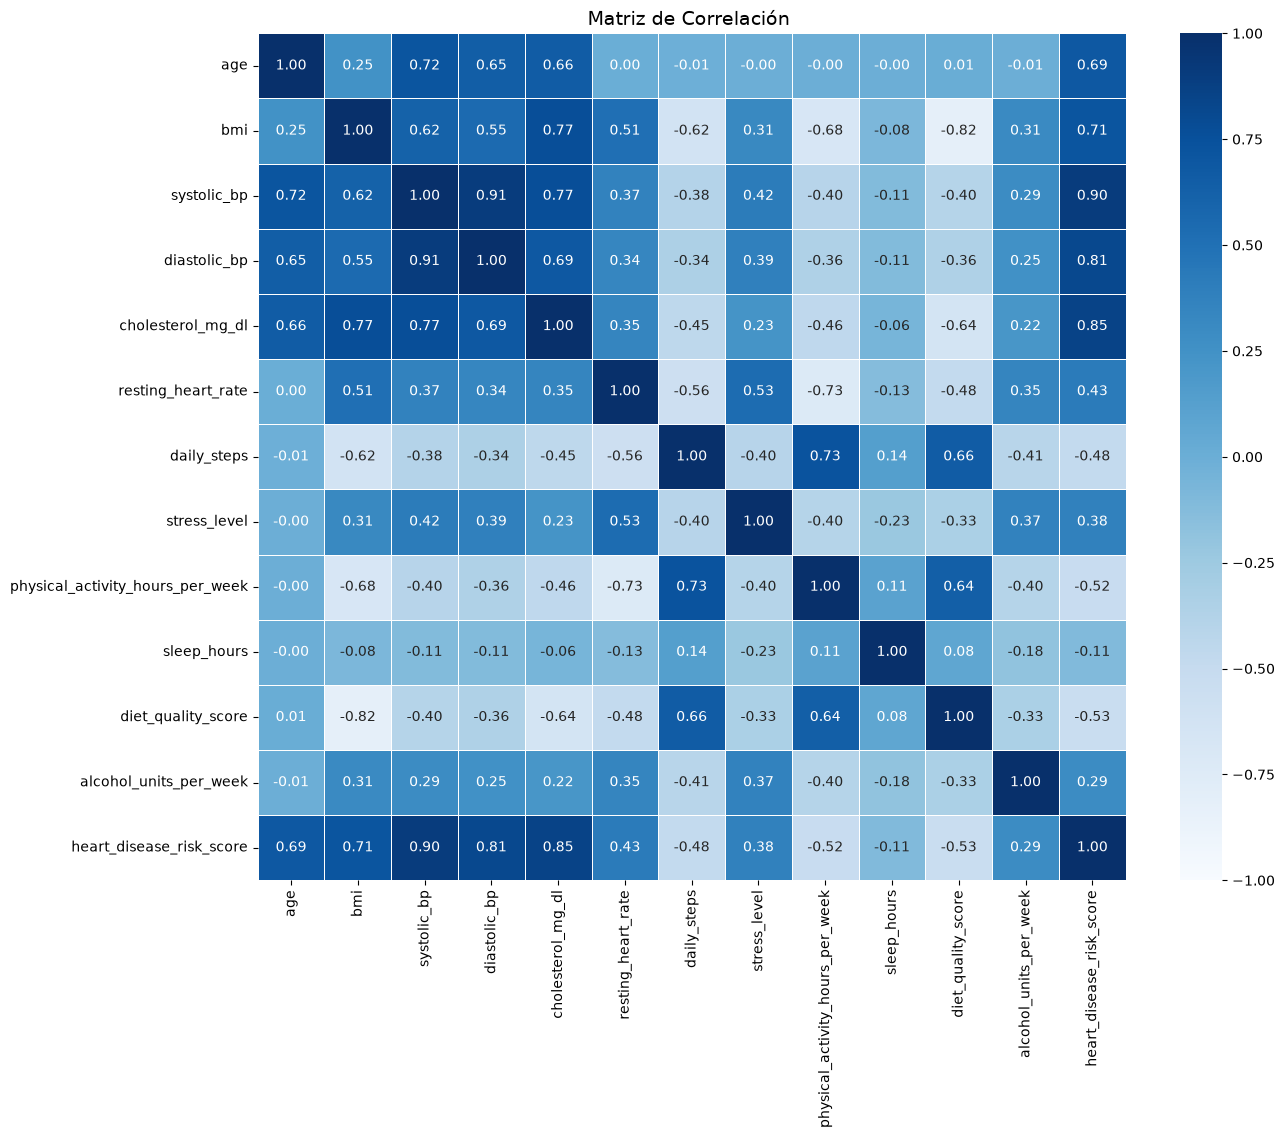

In [25]:
plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(numeric_only=True),annot=True,   fmt=".2f",  cmap="Blues", vmin=-1,  vmax=vmaxCor,  linewidths=0.5)
plt.title("Matriz de Correlación ", fontsize=14)
plt.show()

El gráfico confirma visualmente la fuerte correlación positiva  0.85 obtenida en la matriz anterior. Existe una transición directa y clara: a medida que el colesterol del paciente se desplaza hacia la derecha superando los 250 y tocando máximos de 325, el score de riesgo se eleva proporcionalmente. Esto consolida al colesterol como uno de los predictores médicos con mayor impacto en cuanto al riesgo. 

<Axes: xlabel='cholesterol_mg_dl', ylabel='heart_disease_risk_score'>

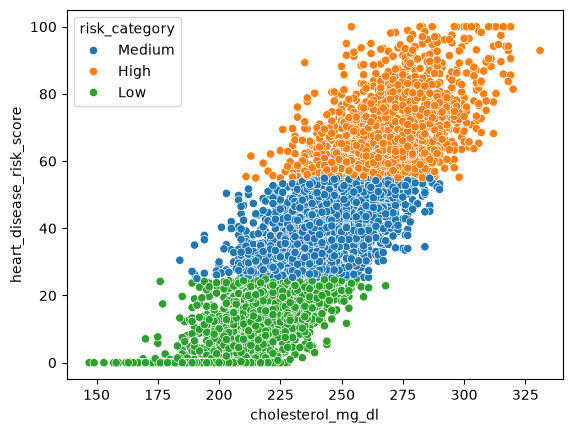

In [26]:
sns.scatterplot(
    data=df,
    x='cholesterol_mg_dl',
    y='heart_disease_risk_score',
    hue='risk_category'
)

ya que nuestro objetivo es la variable nivel de riesgo se creo una copia de dataset a principio se habia optado por utilizar el label encoder pero este ordena los datos de una forma que no nos conviene colocandole 0 a High en su lugar se uso mappara ir en orden, Con esto, los coeficientes representan si una variable aumenta o disminuye el riesgo del paciente.

como vemos las correlaciones con respecto a el riesgo es bajo esto se debe a que ninguna variable define por si sola si la persona tiene alto riesgo sino que es la acumulacion de estos factores pero algunos tienen mas peso que otros. 

In [27]:
df_cor2 = df.copy()
riesgo_map = {"Low": 0, "Medium": 1, "High": 2}
df_cor2["risk_category"] = df_cor2["risk_category"].map(riesgo_map)

corr = df_cor2.corr(numeric_only=True)

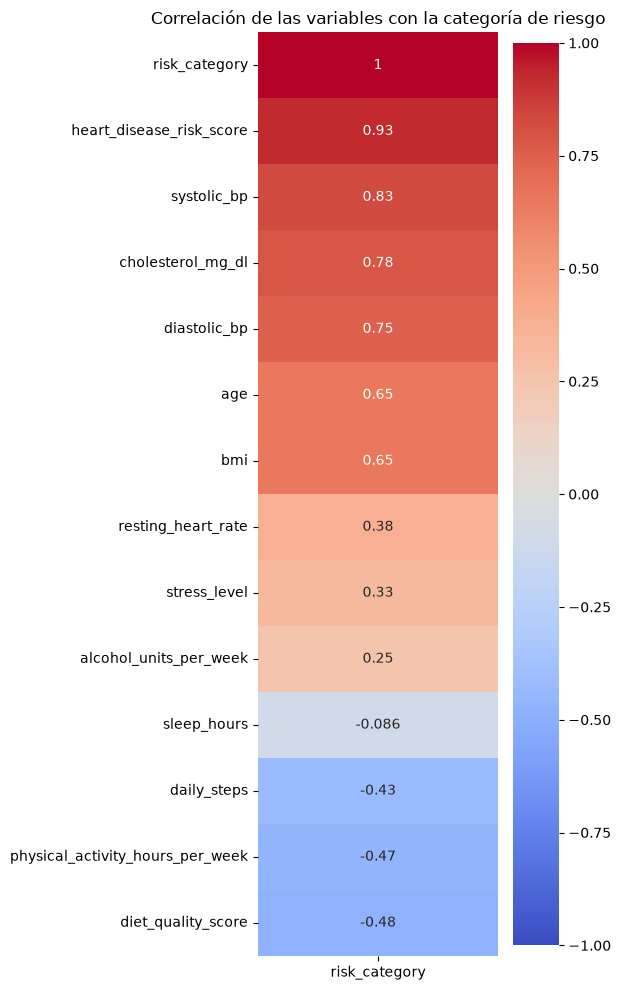

In [28]:

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr[["risk_category"]].sort_values(by="risk_category", ascending=False), annot=True,cmap="coolwarm", vmin=-1,vmax=1,)

plt.title("Correlación de las variables con la categoría de riesgo")
plt.tight_layout()
plt.show()

## ¿Qué relaciones existen entre las variables del conjunto de datos?
Se observaron asociaciones importantes entre variables como la presión arterial, el colesterol, la edad y el puntaje de riesgo cardíaco. Estas relaciones sugieren que ciertos factores fisiológicos y hábitos de vida influyen directamente en el nivel de riesgo cardiovascular de los pacientes, convirtiéndose en variables relevantes para los modelos predictivos.

## Generación de Modelos de Predicción para variables categóricas

Vamos a hacer uso de ramdom forest, se seleccionó Random Forest Classifier debido a su naturaleza no lineal basada en ensambles de árboles de decisión. Dado que el riesgo cardiovascular es un fenómeno que se da por diversos factores donde los factores clínicos y conductuales interactúan de forma compleja y presentan diferentes escalas métricas, Random Forest resulta idóneo al ser inmune al impacto de las magnitudes de las variables. 

In [29]:
df.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


Separacion de las variables como el objetivo es la variable de riesgo de enfermedad esa es la que queremos predecir entonces esa la utilizamos y con respecto a heart_disease_risk_score se descubrio en el analisis de correlacion que esta variable jugo un papel importante ya que se creó haciendo cortes horizontales exactos a partir del puntaje numérico heart_disease_risk_score <25 es Low, entre 25 y 55 es Medium, etc. por eso se tomo la desicion, para forzar a Random Forest y a SVM a que piensen y analicen de verdad. Queremos que el modelo aprenda a predecir el riesgo combinando los factores puros del paciente peso, presión, hábitos.

In [30]:
X = df.drop(['heart_disease_risk_score','risk_category'],axis = 'columns')
y = df['risk_category']
X.shape

(5500, 14)

aplicamoes el label encoder en la variable que no sean numericas

In [31]:
La_smoking = LabelEncoder()
encode = La_smoking.fit_transform(df['smoking_status'])
df.drop('smoking_status',axis= 1, inplace = True)
df['smoking_status'] = encode

La_fahist = LabelEncoder()
encode = La_fahist.fit_transform(df['family_history_heart_disease'])
df.drop('family_history_heart_disease',axis= 1, inplace = True)
df['family_history_heart_disease'] = encode

X = df.drop(['heart_disease_risk_score','risk_category'],axis = 'columns')
y = df['risk_category']

df.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,smoking_status,family_history_heart_disease
0,62,25.0,142,93,247,72,11565,3,5.6,8.2,7,0.7,28.1,Medium,2,0
1,54,29.7,158,101,254,74,4036,8,0.5,6.7,5,4.5,63.0,High,0,0
2,46,36.2,170,113,276,80,3043,9,0.4,4.0,1,20.8,73.1,High,0,0
3,48,30.4,153,98,230,73,5604,5,0.6,8.0,4,8.5,39.5,Medium,1,0
4,46,25.3,139,87,206,69,7464,1,2.0,6.1,5,3.6,29.3,Medium,0,0


In [32]:
df['smoking_status'].value_counts()

smoking_status
2    3627
0     994
1     879
Name: count, dtype: int64

In [33]:
df['family_history_heart_disease'].value_counts()

family_history_heart_disease
0    4134
1    1366
Name: count, dtype: int64

dividimos el dataset en Train y Test

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=11)

Entrenamineto de el modelo de predicción mediante Random Forest

In [35]:

clf1 = RandomForestClassifier(n_jobs=2, random_state=0)

clf1.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

calculamos el score obtenido 

In [36]:
print(f'el score es:{clf1.score(X_test,y_test)}')

el score es:0.8909090909090909


generamos la matriz de confusion para visualizar como el modelo aprendio y en base a eso se pude aprecia y ver como obtuvo ese score de 0.89, El rendimiento del 89% valida que es posible predecir con un alto grado de confianza la categoría de riesgo cardiovascular omitiendo por completo el score numérico continuo. El modelo es matemáticamente robusto y clínicamente útil para la evaluación de nuevos pacientes en escenarios reales.

Este análisis demuestra un entendimiento profundo tanto de la matemática del modelo como de su impacto en el área de la salud.

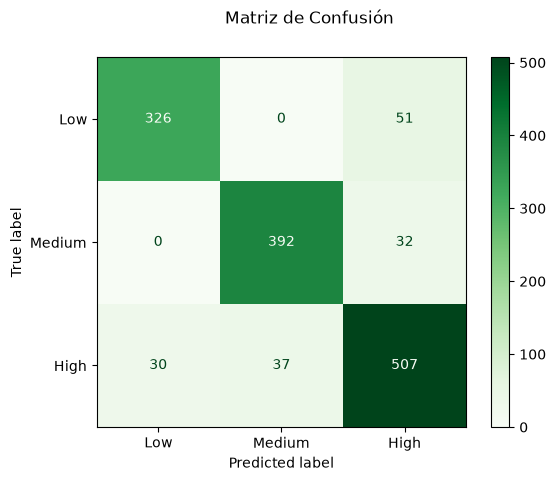

In [37]:
categorias = ['Low','Medium','High']
fig=ConfusionMatrixDisplay.from_estimator(clf1, X_test, y_test,display_labels=categorias, cmap="Greens")  
fig.figure_.suptitle("Matriz de Confusión")
plt.show()


## entrenamineto con SVM 

Se utilizo SVM porque el riesgo cardiovascular presenta fronteras difusas debido a su naturaleza, el SVM permite proyectar las variables clínicas en un espacio multidimensional para trazar hiperplanos de decisión no lineales.

separacion de variable X & Y para el entrenamiento 

In [38]:
X = df.drop(['heart_disease_risk_score','risk_category'],axis = 'columns')
y = df['risk_category']

division del dataset 

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=1, test_size=0.3)

escalado a los datos

In [40]:
scalado_X = StandardScaler()
X_train_escalado = scalado_X.fit_transform(X_train)
X_test_escalado = scalado_X.transform(X_test) 

entrenamiento del modelo svm con kernel rbf 

In [41]:
svm_rbf = SVC(kernel='rbf',C=50, gamma=0.1,probability=True)
svm_rbf.fit(X_train_escalado, y_train)

c:\Users\KEVIN CAMPINES\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",50
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


predicciones basadas en base al conjunto de prueba 

In [42]:
predicted = svm_rbf.predict(X=X_test_escalado)
print(predicted)

['Medium' 'Medium' 'Low' ... 'Medium' 'Medium' 'Low']


calculamos el score del modelo

In [43]:
print(f'El score del modelo es= {svm_rbf.score(X_test_escalado,y_test):.2%}')

El score del modelo es= 91.82%


matriz de confusion de los datos de test

Clasificación de Riesgo Bajo (Low): El modelo muestra su desempeño más alto en esta categoría, clasificando correctamente al 95% de los pacientes sanos, con un margen de error muy bajo hacia la categoría moderada ($5.5\%$) y un impecable $0\%$ hacia riesgo alto.
Clasificación de Riesgo Alto (High): El algoritmo identificó con éxito al 90% de los pacientes en estado crítico. Médicamente esto es fantástico. Además, el modelo redujo a 0% el error de diagnosticar por completo como sanos (Low) a estos pacientes en peligro, derivando el $9.5\%$ restante a riesgo moderado.
Clasificación de Riesgo Moderado (Medium): Registra una efectividad del 90%. El porcentaje de error se distribuye de manera segura en un $5.7\%$ hacia riesgo bajo y solo un $3.8\%$ de falsos positivos hacia riesgo alto.

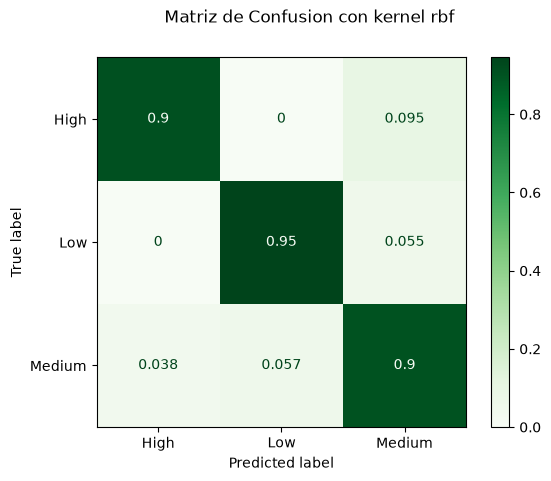

In [44]:
categorias = svm_rbf.classes_
fig=ConfusionMatrixDisplay.from_estimator(svm_rbf, X_test_escalado,y_test,display_labels=categorias, cmap="Greens",  normalize='true')  
fig.figure_.suptitle("Matriz de Confusion con kernel rbf")
plt.show()

In [58]:
joblib.dump(svm_rbf, 'modelo_svm_clasificacion.pkl')
joblib.dump(scalado_X, 'escalador_svm.pkl')

['escalador_svm.pkl']

## ¿Cuál de los modelos de clasificación obtiene el mejor desempeño?
el modelo de Support Vector Machine (SVM) es seleccionado como el modelo óptimo para el despliegue en este proyecto, fundamentado en los siguientes criterios técnicos:

Mayor Precisión General: SVM superó a Random Forest con un 91.82% de exactitud frente al 89%. El análisis de las matrices demuestra que SVM es más seguro. Mientras que Random Forest clasificó erróneamente a varios pacientes de alto riesgo en la categoría Low, el SVM redujo esa tasa de error crítico a un 0.0%, asegurando que ningún paciente con riesgo severo sea ignorado o enviado a casa con un diagnóstico erróneo de "bajo riesgo".

## Generación de Modelos de Predicción para variables continuas

Para el modelo de regresion utilizaremos como variable objetivo es puntaje de riesgo (heart_disease_risk_score) quitamos risk_category ya que esta se sabe que esta construida en base al puntaje de riesgo por lo tanto si la usamos el modelo arroja un score de 1 y queremos que aprenda. 

In [46]:
X = df.drop(columns=['heart_disease_risk_score','risk_category'],axis = 'columns')
y = df['heart_disease_risk_score']

In [47]:
X_train, X_test, y_train, y_test = train_test_split( X,y,random_state=11)
print(f'El conjunto original tenia {len(df)} instancias, el conjunto de train tiene {len(X_train)} y el conjunto de test {len(X_test)} instancias.')

El conjunto original tenia 5500 instancias, el conjunto de train tiene 4125 y el conjunto de test 1375 instancias.


entrenamiento del modelo

In [48]:
linear_regression = LinearRegression()
linear_regression.fit(X=X_train, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.46, 0.8 , 0.41,...,-0.01,-7.04, 9.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['age','bmi','systolic_bp',...,'alcohol_units_per_week','smoking_status', 'family_history_heart_disease']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-84.24
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [49]:

terminos = [
    f"{coef:0.4f}*({col})" for coef, col in zip(linear_regression.coef_, X.columns)
]  
ecuacion_completa = " + ".join(terminos)
print(
    f"Ecuación resultante: y = {linear_regression.intercept_:0.4f} + {ecuacion_completa}"
)

Ecuación resultante: y = -84.2376 + 0.4612*(age) + 0.7990*(bmi) + 0.4116*(systolic_bp) + -0.0143*(diastolic_bp) + 0.1287*(cholesterol_mg_dl) + -0.0216*(resting_heart_rate) + -0.0000*(daily_steps) + 0.8540*(stress_level) + -1.0613*(physical_activity_hours_per_week) + -0.2004*(sleep_hours) + -0.9653*(diet_quality_score) + -0.0060*(alcohol_units_per_week) + -7.0388*(smoking_status) + 9.2521*(family_history_heart_disease)


In [50]:
predicted = linear_regression.predict(X_test)
expected = y_test

# Imprimir cada 5 valores de la predicción 
for p, e in zip(predicted[::5], expected[::5]):
     print(f'predicted: {p:.2f}, expected: {e:.2f}')
        
print(f'El score obtenido por el modelo es {linear_regression.score(X_test, y_test)}')

predicted: -2.72, expected: 0.00
predicted: 55.67, expected: 52.30
predicted: 21.01, expected: 17.50
predicted: 0.34, expected: 0.00
predicted: 17.10, expected: 13.90
predicted: 57.74, expected: 61.60
predicted: 52.63, expected: 54.70
predicted: 61.45, expected: 61.60
predicted: 55.23, expected: 58.90
predicted: 19.81, expected: 21.70
predicted: 34.24, expected: 25.70
predicted: -24.25, expected: 0.00
predicted: 40.27, expected: 40.20
predicted: 41.83, expected: 40.70
predicted: 40.94, expected: 36.40
predicted: 28.54, expected: 25.80
predicted: 61.15, expected: 62.40
predicted: 52.41, expected: 53.00
predicted: 75.72, expected: 84.70
predicted: 44.33, expected: 41.80
predicted: 17.01, expected: 15.10
predicted: 32.61, expected: 34.10
predicted: 46.74, expected: 46.60
predicted: 58.66, expected: 63.70
predicted: 45.52, expected: 42.50
predicted: 17.98, expected: 19.60
predicted: 34.12, expected: 31.30
predicted: 35.62, expected: 34.70
predicted: 38.09, expected: 39.00
predicted: 23.18,

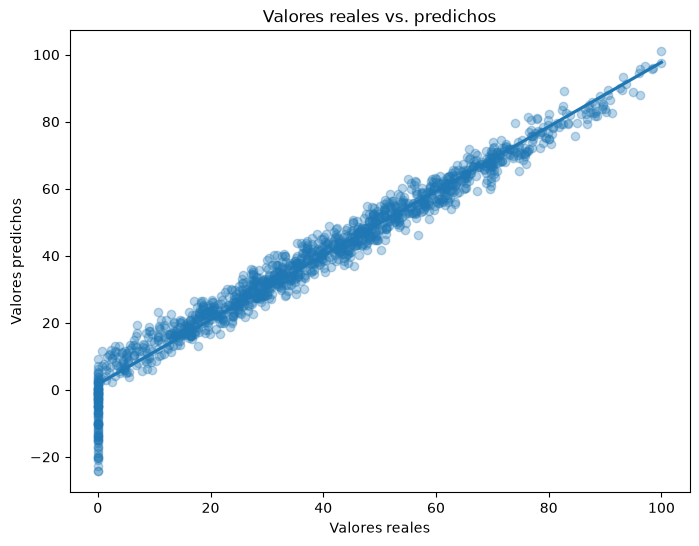

In [51]:
plt.figure(figsize=(8,6))

sns.regplot(x=y_test,y=predicted,scatter_kws={'alpha':0.3}
)

plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs. predichos')

plt.show()

## Usando RamdomForestRegresor

In [52]:
X = df.drop(columns=['heart_disease_risk_score','risk_category'],axis = 'columns')
y = df['heart_disease_risk_score']

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=11)

In [54]:
clf3 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    max_samples=0.5,
    random_state=42
)

clf3.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `"

In [55]:
print(f'El score del modelo es:{clf3.score(X_test,y_test)}')

El score del modelo es:0.9614476866140735


In [56]:
y_pred = clf3.predict(X)

df_resultado = pd.DataFrame({
    'valor_Real': y,
    'valor_Predicho': y_pred
})

print(df_resultado.head())

   valor_Real  valor_Predicho
0        28.1       27.186030
1        63.0       56.621213
2        73.1       76.682879
3        39.5       39.834507
4        29.3       25.135839


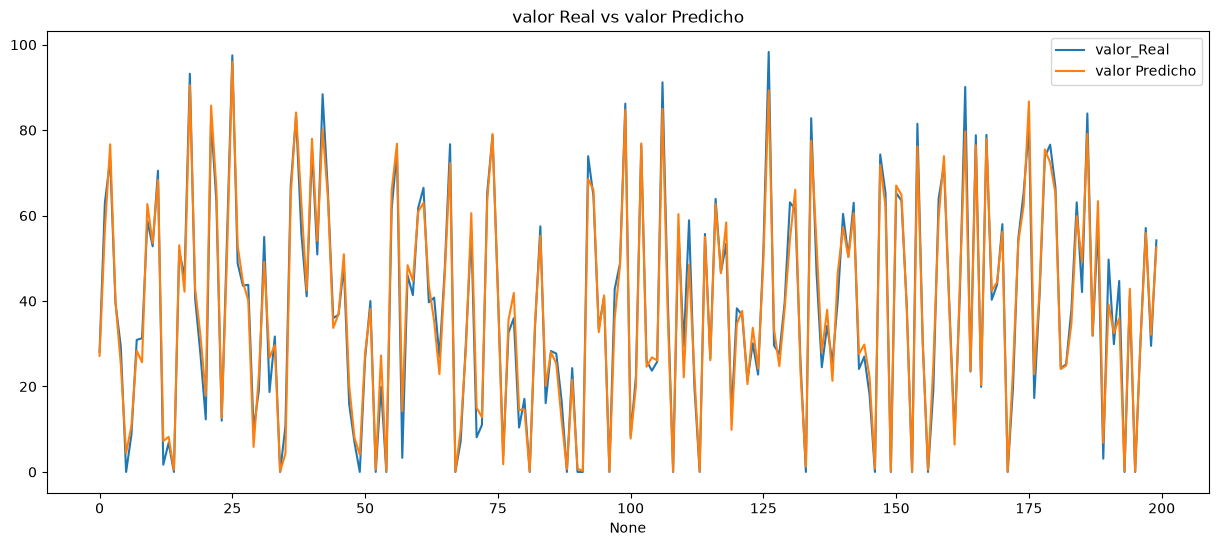

In [57]:
df_plot = df_resultado.iloc[0:200]

plt.figure(figsize=(15,6))

sns.lineplot(
    data=df_plot,
    x=df_plot.index,
    y='valor_Real',
    label='valor_Real'
)

sns.lineplot(
    data=df_plot,
    x=df_plot.index,
    y='valor_Predicho',
    label='valor Predicho'
)

plt.title('valor Real vs valor Predicho')
plt.ylabel('')
plt.legend()
plt.show()

## Qué modelo predice con mayor precisión el puntaje de riesgo de enfermedad cardíaca?

La diferencia entre ambos modelos es pequeña, lo que indica que ambos son altamente precisos. Sin embargo, la Regresión Lineal Múltiple obtuvo el mejor desempeño y, además, ofrece una mayor facilidad de interpretación al permitir analizar el efecto de cada variable independiente sobre el puntaje de riesgo cardíaco